# 📊 Análisis del paro en España con Python

## 📌 Introducción
En este proyecto realizamos un análisis exploratorio de datos sobre el paro en España utilizando datos públicos.
El objetivo es entender cómo ha evolucionado la tasa de paro a lo largo del tiempo mediante un enfoque práctico con Python.

## 📦 1. Importación de librerías

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 📂 2. Carga de datos

El dataset utiliza `;` como separador, por lo que debemos indicarlo al cargarlo.

In [19]:
ruta = Path("../data/paro_2002_2025.csv")
df = pd.read_csv(
    ruta,
    sep=";",
    encoding="utf-8",
    decimal=",",
    skipinitialspace=True
)
df.head()

,Sexo,Provincias,Tasas,Periodo,Total
0,Ambos sexos,Total Nacional,Tasa de actividad,2025T4,"58,94"
1,Ambos sexos,Total Nacional,Tasa de actividad,2025T3,"59,3"
2,Ambos sexos,Total Nacional,Tasa de actividad,2025T2,"59,03"
3,Ambos sexos,Total Nacional,Tasa de actividad,2025T1,"58,57"
4,Ambos sexos,Total Nacional,Tasa de actividad,2024T4,"58,49"


## 🔍 3. Exploración inicial

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45792 entries, 0 to 45791
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Sexo        45792 non-null  str  
 1   Provincias  45792 non-null  str  
 2   Tasas       45792 non-null  str  
 3   Periodo     45792 non-null  str  
 4   Total       45792 non-null  str  
dtypes: str(5)
memory usage: 1.7 MB


Observamos que la columna `Total` no es numérica debido al uso de comas en los decimales.

## 🧹 4. Limpieza de datos

Convertimos la columna `Total` a formato numérico:

In [21]:
df["Total"] = (
    df["Total"]
    .str.replace(",", ".", regex=False)
)

df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

## 🎯 5. Filtrado de datos

Nos centramos únicamente en la tasa de paro:

In [22]:
paro = df[df["Tasas"] == "Tasa de paro de la población"]

Filtramos los datos a nivel nacional:

In [23]:
paro_nacional = paro[paro["Provincias"] == "Total Nacional"]

# Extraer el año del campo Periodo
paro_nacional["Año"] = paro_nacional["Periodo"].str[:4]
paro_nacional.head()

,Sexo,Provincias,Tasas,Periodo,Total,Año
96,Ambos sexos,Total Nacional,Tasa de paro de la población,2025T4,9.93,2025
97,Ambos sexos,Total Nacional,Tasa de paro de la población,2025T3,10.45,2025
98,Ambos sexos,Total Nacional,Tasa de paro de la población,2025T2,10.29,2025
99,Ambos sexos,Total Nacional,Tasa de paro de la población,2025T1,11.36,2025
100,Ambos sexos,Total Nacional,Tasa de paro de la población,2024T4,10.61,2024


## 📅 6. Ordenar por periodo

In [24]:
paro_nacional = paro_nacional.sort_values("Periodo")

paro_anual = paro_nacional.groupby("Año")["Total"].mean().reset_index()

## 📈 7. Visualización

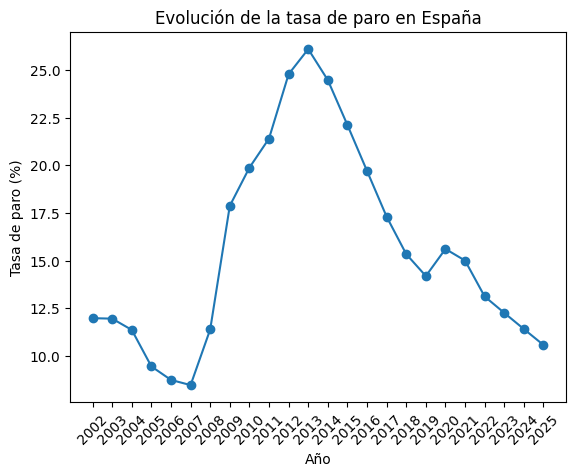

In [25]:
plt.figure()
plt.plot(paro_anual["Año"], paro_anual["Total"], marker="o")
plt.xticks(rotation=45)
plt.title("Evolución de la tasa de paro en España")
plt.xlabel("Año")
plt.ylabel("Tasa de paro (%)")
# Guardar la imagen
plt.savefig("../images/evolucion_paro_espana.png", dpi=300, bbox_inches="tight")
plt.savefig("../images/evolucion_paro_espana.svg")

# Mostrar gráfico
plt.show()

## 🧠 8. Análisis

A partir del gráfico podemos observar:
* Un aumento exponencial del paro durante la crisis de 2008.
* Un pico alrededor de 2013.
* Una tendencia descendente en los últimos años sin llegar a recuperar los valores previos a la crisis.
* Un impacto visible en 2020 (pandemia).

## 🏁 9. Conclusiones

Este análisis muestra cómo con un dataset sencillo, podemos:
* Trabajar con datos reales.
* Aplicar un flujo completo de análisis.
* Extraer conclusiones relevantes.